In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_recall_curve, auc, f1_score, 
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE

# Helper function to evaluate models
def evaluate_model(y_test, y_pred, y_prob, model_name):
    print(f"\n--- {model_name} Evaluation ---")
    
    # F1 Score
    f1 = f1_score(y_test, y_pred)
    
    # AUC-PR
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    auc_pr = auc(recall, precision)
    
    print(f"F1 Score: {f1:.4f}")
    print(f"AUC-PR: {auc_pr:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix: {model_name}')
    plt.show()
    
    return {"model": model_name, "f1": f1, "auc_pr": auc_pr}


--- Logistic Regression (E-commerce) Evaluation ---
F1 Score: 0.6002
AUC-PR: 0.6632


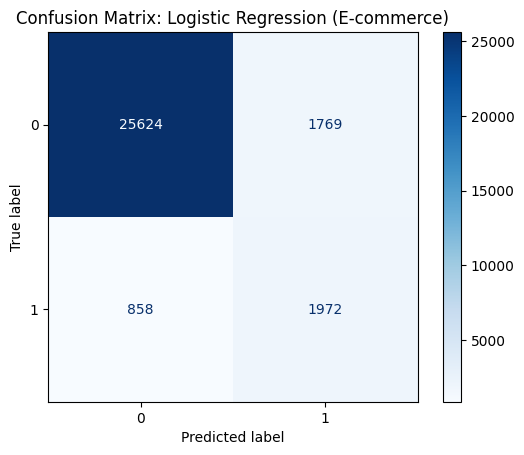


--- Random Forest (E-commerce) Evaluation ---
F1 Score: 0.6201
AUC-PR: 0.7072


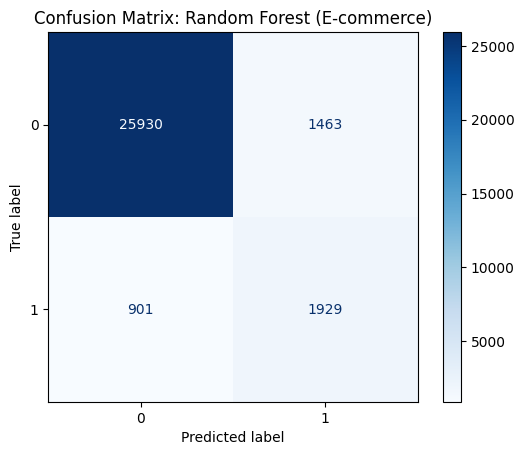

In [2]:
# 1. Load data
df_fraud = pd.read_csv('../data/processed/fraud_data_final.csv')
X = df_fraud.drop(columns=['class', 'user_id', 'signup_time', 'purchase_time', 'device_id', 'ip_address', 'country', 'lower_bound_ip_address', 'upper_bound_ip_address'], errors='ignore')
y = df_fraud['class']

# 2. Stratified Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 3. SMOTE on Training set only
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

# --- MODEL 1: Logistic Regression (Baseline) ---
lr_fraud = LogisticRegression(max_iter=1000)
lr_fraud.fit(X_train_res, y_train_res)

y_pred_lr = lr_fraud.predict(X_test)
y_prob_lr = lr_fraud.predict_proba(X_test)[:, 1]

lr_results = evaluate_model(y_test, y_pred_lr, y_prob_lr, "Logistic Regression (E-commerce)")

# --- MODEL 2: Random Forest (Ensemble) ---
rf_fraud = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_fraud.fit(X_train_res, y_train_res)

y_pred_rf = rf_fraud.predict(X_test)
y_prob_rf = rf_fraud.predict_proba(X_test)[:, 1]

rf_results = evaluate_model(y_test, y_pred_rf, y_prob_rf, "Random Forest (E-commerce)")


--- Random Forest (Bank) Evaluation ---
F1 Score: 0.5714
AUC-PR: 0.8290


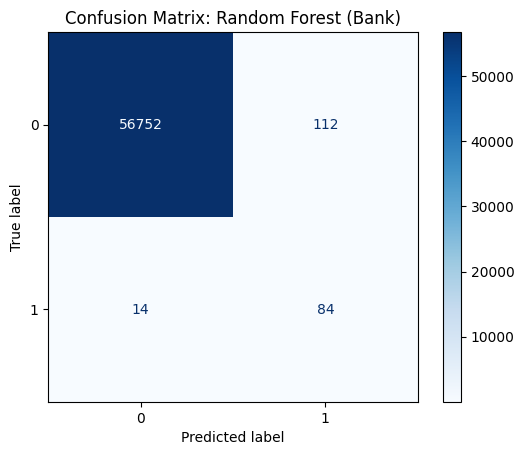

In [3]:
# 1. Load data
df_credit = pd.read_csv('../data/processed/creditcard_final.csv')
X_c = df_credit.drop(columns=['Class'])
y_c = df_credit['Class']

# 2. Split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_c, y_c, test_size=0.2, stratify=y_c, random_state=42)

# 3. SMOTE
X_train_c_res, y_train_c_res = sm.fit_resample(X_train_c, y_train_c)

# --- MODEL 3: Random Forest (Bank) ---
rf_credit = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_credit.fit(X_train_c_res, y_train_c_res)

y_pred_rfc = rf_credit.predict(X_test_c)
y_prob_rfc = rf_credit.predict_proba(X_test_c)[:, 1]

credit_results = evaluate_model(y_test_c, y_pred_rfc, y_prob_rfc, "Random Forest (Bank)")

In [4]:
import joblib
import os

os.makedirs('../models', exist_ok=True)
joblib.dump(rf_fraud, '../models/random_forest_fraud.pkl')
joblib.dump(rf_credit, '../models/random_forest_credit.pkl')

print("Models saved successfully in /models folder!")

Models saved successfully in /models folder!
